## Mini Project: Solving inverse problems with denoising priors.


In this mini project, you will compare different Plug-and-Play (PnP) and diffusion-based iterative image restoration algorithms. These methods make use of image denoisers as regularization priors. These algorithms will be applied for image deblurring. In particular, you will compare standard PnP versus diffusion models, and implement a new algorithm based on diffusion models.

In [ ]:
%%capture
pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv

In [ ]:
import torch
import deepinv as dinv
from torchvision import transforms
from deepinv.utils.demo import load_dataset, load_degradation

In [ ]:
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

### Bencharmarking PnP and diffusion models for image deblurring

The goal of this section is to identify and compare the performance of PnP and diffusion-based iterative algorithms. We will work on images blurred with mild and severe blurs.

The goal is for you to find the best algorithm to reconstruct the following images, for which we don't provide the groundtruth reconstruction

The first one is blurred with a large gaussian kernel (3,3) and noised with Gaussian noise with standard deviation $0.02$.

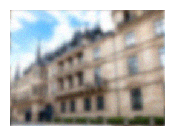

In [ ]:
y = dinv.utils.load_example('y_gaussian.png')
dinv.utils.plot(y)

Here is the command to have access to the corresponding kernel:

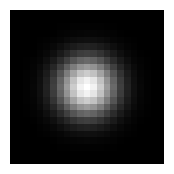

In [ ]:
kernel = dinv.physics.blur.gaussian_blur(sigma=(3, 3))
dinv.utils.plot(kernel)

The second one is blurred with a mild motion kernel and noised with Gaussian noise with standard deviation $0.05$.

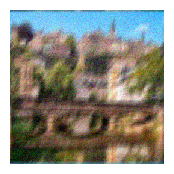

In [ ]:
y = dinv.utils.load_example('y_motion.png')
dinv.utils.plot(y)

Here is the command to have access to the corresponding kernel:

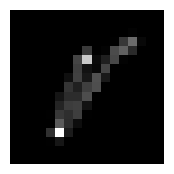

In [ ]:
kernel = load_degradation("Levin09.npy",  "kernels", index=1).unsqueeze(0).unsqueeze(0)
dinv.utils.plot(kernel)

For validating your algorithm with groundtruth data, you can for example use the CBSD68 dataset.

In [ ]:
dataset_name = 'CBSD68'
img_size = 128
num_images = 10
val_transform = transforms.Compose([transforms.CenterCrop(img_size), transforms.ToTensor()])
dataset = load_dataset(dataset_name, transform=val_transform)
eval_images = [dataset[i][0].to(device) for i in range(num_images)]

Compare the performance between different PnP algorithms and diffusion-based algorithms for solving a deblurring problem.

- **Hint 1** You can explore different denoisers with different architecture size.
- **Hint 2** For PnP, you can try different optimization algorithms for integrating the PnP prior. Try different parameters (stepsize, denoising noise level ...) for optimal performance.
- **Hint 3** For using diffusion models, you can refer to the different demos from the documentation (`demo_ddrm.py`, `demo_diffpir.py`, `demo_diffusion_sde.py`) and compare several algorithms. It might be necessary to play with the corresponding hyperparameters. Check on which dataset / image size each denoiser has been trained. For example :

In [ ]:
denoiser = dinv.models.DRUNet()

Downloading: "https://huggingface.co/deepinv/drunet/resolve/main/drunet_deepinv_color_finetune_22k.pth?download=true" to /root/.cache/torch/hub/checkpoints/drunet_deepinv_color_finetune_22k.pth
100%|██████████| 125M/125M [00:02<00:00, 60.7MB/s]


In [ ]:
denoiser = dinv.models.DiffUNet()

Downloading: "https://huggingface.co/deepinv/diffunet/resolve/main/diffusion_ffhq_10m.pt?download=true" to /root/.cache/torch/hub/checkpoints/diffusion_ffhq_10m.pt
100%|██████████| 357M/357M [00:02<00:00, 159MB/s]


In [ ]:
denoiser = dinv.models.NCSNpp(pretrained="download").to(device)

Downloading: "https://huggingface.co/deepinv/edm/resolve/main/ncsnpp-ffhq64-uncond-ve.pt?download=true" to /root/.cache/torch/hub/checkpoints/ncsnpp-ffhq64-uncond-ve.pt
100%|██████████| 240M/240M [00:02<00:00, 105MB/s] 


In [ ]:
#TODO

In [ ]:
#TODO

### Going further with diffusion models

In the demo [`demo_diffusion_sde.py`](https://deepinv.github.io/deepinv/auto_examples/sampling/demo_diffusion_sde.html), we experience with the DPS sampling algorithm, implemented via the DPS version of a `NoisyDataFidelity` (refer to the demo for more details). We also choose the variance exploding diffusion, discretized with the Euler solver.

- First, you can explore on the deblurring problem different diffusion algorithms (Variance Preserving, Variance Exploding ...) and discretization methods (Euler, Heun).
- Second, you can implement a different  `NoisyDataFidelity` terms for approximating the untractable $\log p(y|x_t)$.  `https://arxiv.org/pdf/2410.00083` (Figure 1) provides a survey of different approximations. For example, you can try to implement the Score-SDE, ILRV or PiGDM methods.





In [ ]:
# TODO